## 1. Import and warehouse data.
## Import required Libraries

In [1]:
import numpy as np 
import pandas as pd

# Plots
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Data processing, metrics and modeling
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score


import warnings 
warnings.filterwarnings('ignore')

## Load, Create a database in MYSQL server using MYSQL workbench and Merge the datasets

In [2]:
import mysql.connector

mydb = mysql.connector.connect(
  host="localhost",              # hostname
  user="root",                   # the user who has privilege to the db
  passwd="hp52a2973",            # password for the user
  auth_plugin = 'mysql_native_password'

)
print(mydb)

In [3]:
# Creating a database in MySQL server using MYSQL workbench 
# Database 'Telecom' created in MySQL workbench

mycursor = mydb.cursor()
mycursor.execute("SHOW DATABASES")

for x in mycursor:
  print(x)

('company',)
('db',)
('HR_EMP',)
('information_schema',)
('mindki',)
('mysql',)
('performance_schema',)
('Redbus',)
('sys',)
('Telecom',)
('telecomm',)
('Travego',)


In [4]:
# Importing the dataset ‘TelecomCustomerChurn1’ from MySQL Workbench
# Reading the first 5 rows from the first data set.

df1 = pd.read_csv("TelcomCustomerChurn1.csv")
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No


In [5]:
# The first data consists of 7043 rows and 10 columns 

df1.shape

(7043, 10)

In [6]:
# The total entries in the first data is 7043*10

df1.size

70430

In [7]:
# check the basic information about the first dataset

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customerID       7043 non-null   object
 1   gender           7043 non-null   object
 2   SeniorCitizen    7043 non-null   int64 
 3   Partner          7043 non-null   object
 4   Dependents       7043 non-null   object
 5   tenure           7043 non-null   int64 
 6   PhoneService     7043 non-null   object
 7   MultipleLines    7043 non-null   object
 8   InternetService  7043 non-null   object
 9   OnlineSecurity   7043 non-null   object
dtypes: int64(2), object(8)
memory usage: 550.4+ KB


In [8]:
# Importing the dataset ‘TelecomCustomerChurn2’ from MySQL Workbench
# Reading the first 5 rows from the second data set.

df2 = pd.read_csv("TelcomCustomerChurn2.csv")

df2.head()

,customerID,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# The second data consists of 7043 rows and 12 columns 

df2.shape

(7043, 12)

In [10]:
# The total entries in the second data is 7043*12

df2.size

84516

In [11]:
# checking the basic information about the dataset

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   OnlineBackup      7043 non-null   object 
 2   DeviceProtection  7043 non-null   object 
 3   TechSupport       7043 non-null   object 
 4   StreamingTV       7043 non-null   object 
 5   StreamingMovies   7043 non-null   object 
 6   Contract          7043 non-null   object 
 7   PaperlessBilling  7043 non-null   object 
 8   PaymentMethod     7043 non-null   object 
 9   MonthlyCharges    7043 non-null   float64
 10  TotalCharges      7043 non-null   object 
 11  Churn             7043 non-null   object 
dtypes: float64(1), object(11)
memory usage: 660.4+ KB


In [12]:
# Merging the two dataframes using outer join on 'customerID', it being the common identifier in both dataframes
# Reading the first 5 rows from the merged data set.

df3 = pd.merge(left = df1 , right = df2 , how = 'inner' , on = 'customerID')

df3.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## The dataframe includes information about:

Customers who left within the last month – the column is called Churn

Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, streaming TV and movies

Customer account information - how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

Demographic info about customers – gender,Senior Citizen,Partner,Dependents

In [13]:
# Data set has 7043 rows and 21 columns

df3.shape


(7043, 21)

In [14]:
# Data set total entries = 7043*21

df3.size

147903

In [15]:
# All the column variables involved in the dataframe

df3.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [16]:
# There are a total of 18 object type, 2 int64 type and 1 float64 type variables
# All variables are non-null
# TotalCharges column is object type, which should be numeric data type.
# SeniorCitizen is described as numeric type
# Churn is the target variable

df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
# let's look at the statistical aspects of the dataframe
df3.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##  2. Data cleansing and Exploratory data analysis: [ Score: 8 point ]

Data Cleansing:
1. Check the percentage of missing values in each column of the data frame. 
2. Drop the missing values if there are any. 
3. Check if there are any duplicate records in the dataset? If any drop them.
4. Drop the columns which you think redundant for the analysis.
5. Encode the categorical variables.
6. Write all the above steps in functions for modularity.

Exploratory Data Analysis:
1. Perform detailed statistical analysis on the data.
2. Perform a detailed univariate, bivariate, and multivariate analysis with appropriate detailed comments
   after each analysis.

## Data Cleaning

In [18]:
# Checking Null values
# There are no NULL values in the dataset, hence it is clean.

df3.isnull().sum()*100/df3.shape[0]

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [19]:
# 'TotalCharges' is given to be object datatype
# Converting TotalCharges to a numerical data type

df3['TotalCharges'] = pd.to_numeric(df3.TotalCharges, errors='coerce')

In [20]:
# there are 11 missing values for TotalCharges

df3.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [21]:
# Showing all the 11 rows which have NaN values in 'TotalCharges' and shpuld be removed

df3[df3['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [22]:
# Since the number of missing values out of 7043 is only 11 and may not have much impact on the final outcome.
# we therefore remove the missing values in 'TotalCharges' variable column 

df3.dropna(inplace = True)

# Reckecking if all the null values are actually removed

df3.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
# replacement_value = (df3['TotalCharges']/df3['MonthlyCharges']).median()*df3['MonthlyCharges']

In [24]:
# df3['TotalCharges'] = replacement_value.where(df3['TotalCharges'] == np.nan, other =df3['TotalCharges'])

In [25]:
# There is a lot of difference in the mean and median values of TotalCharges

df3['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [26]:
# Checking for any duplicated record in data. No duplicate record found.

df3.duplicated().sum()

0

## Exploratory Data Analysis

## Univariate Analysis

In [27]:
# Out of total 7043 customers 5174 didn't Churn.

df3.Churn.describe()

count     7032
unique       2
top         No
freq      5163
Name: Churn, dtype: object

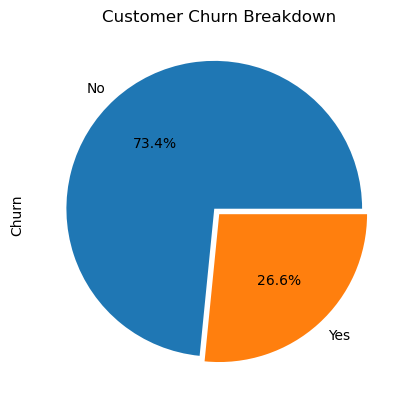

In [28]:
# Only 26.6% of total customers churn

df3['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode = (0.05,0)) # Explode first slice

plt.title('Customer Churn Breakdown')

plt.show()

<AxesSubplot:xlabel='tenure', ylabel='Churn'>

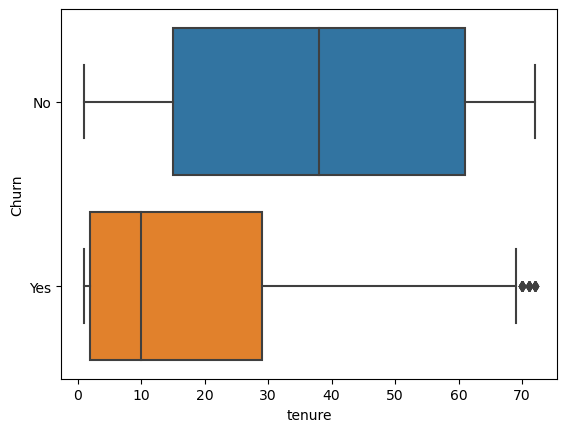

In [29]:
# the customers who do not churn, they tend to stay for a longer tenure with the telecom company.
# Most of the customers churned during the early tenure 
# Customer with more tenure tends to churn less.
# The customers who churned has a few tenure outliers above the maximum tenure of almost 70 months, but the max 
# max tenure is 72 months


sns.boxplot(x = 'tenure', y = 'Churn' , data=df3)

<AxesSubplot:xlabel='MonthlyCharges', ylabel='Churn'>

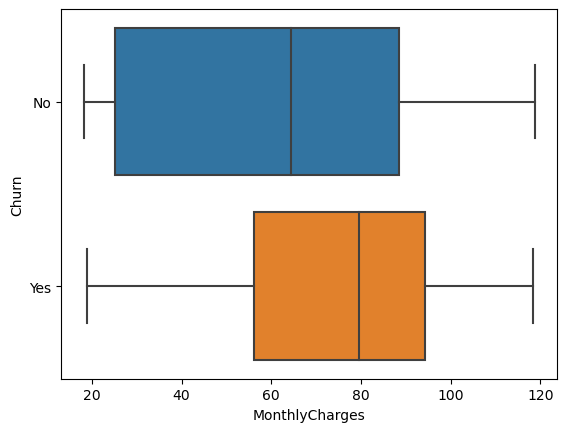

In [30]:
# Higher the MonthlyCharges more the churn
# median monthly charges of customers those churned are higher than the 
# median monthly charges of the customers those did not.

sns.boxplot(x='MonthlyCharges', y='Churn', data=df3)

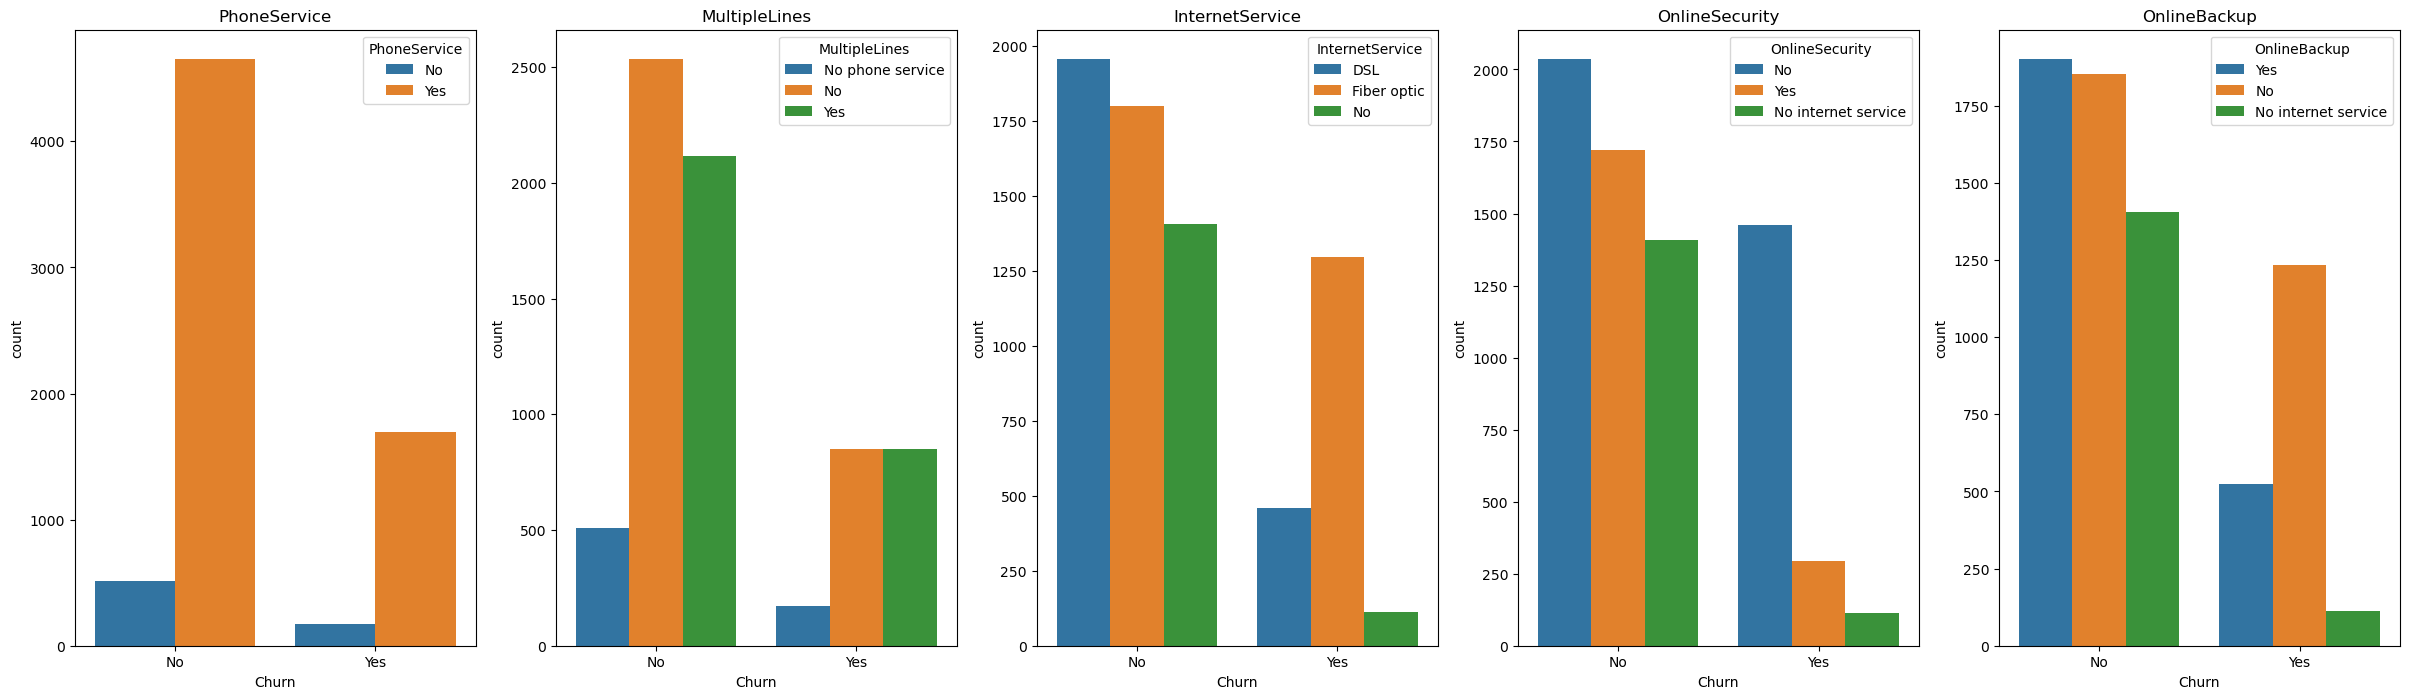

In [31]:
# As the number of categorical variables is large. In order to have a bivariate analysis of all these variables
# we divide these into two lists cat_colsA and cat_colsB and plot separately, so as to have a clear visual plot 
# of all these variables

cat_colsA = ['PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup']
cat_colsB = ['DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

plt.figure(figsize=(30,8))

for i, col in enumerate(cat_colsA):
    ax = plt.subplot(1, len(cat_colsA), i+1)
    sns.countplot(x ="Churn", hue = str(col), data = df3)
    ax.set_title(f"{col}")

## Explanation:

PhoneService: we can observe that most customers have this service whether they churned or stayed.
              Only a few did not have this facility
        
MultipleLines: It is observed that the customers who do not have multiple lines did not churn 
               followed by those who had multiple lines. 
        
InternetService: we can observe that DSL is the top choice for internetservice who did not churn
                 and Fibre optic customers are highest who churned.
        
OnlineSecurity: Those customers who churned are highly unlikely to purchase this feature as is clear 
                from the plot. Even the highest number of customers who did'nt churn do not have this facility.
    
OnlineBackup: As is evident from the plot customers who churned are least likely to choose this feature.
              There are almost equal number of customers who have this feature and also who did'nt have. 

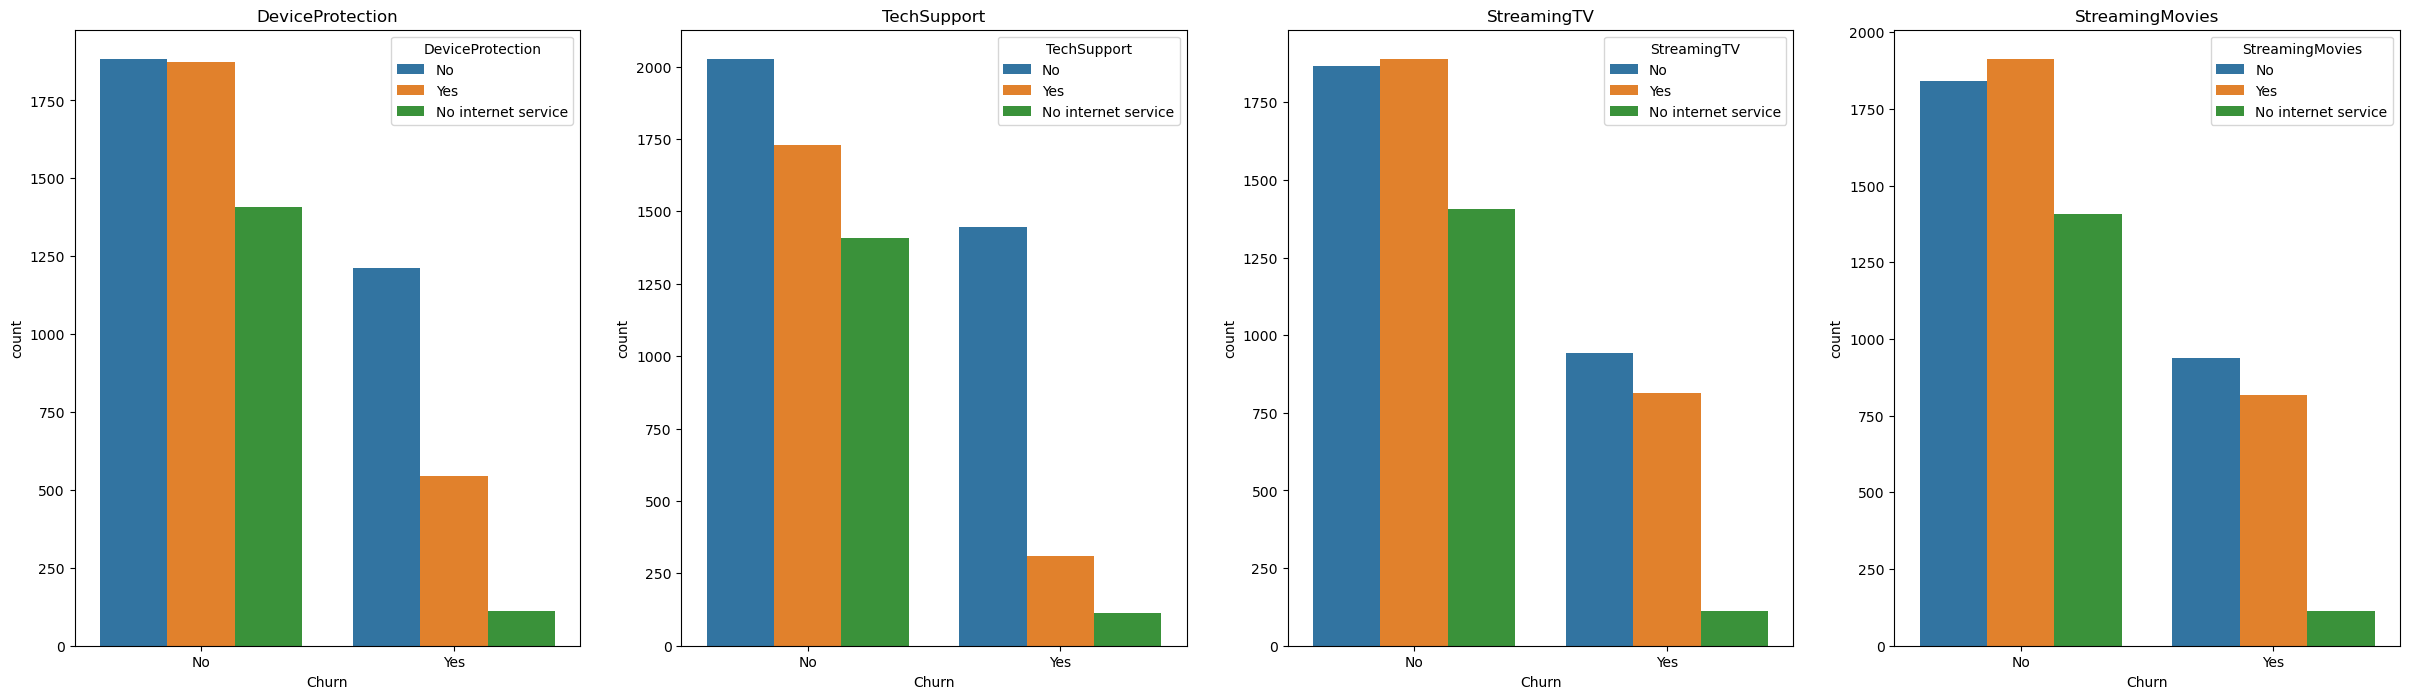

In [32]:
plt.figure(figsize=(30,8))

for i, col in enumerate(cat_colsB):
    ax = plt.subplot(1, len(cat_colsB), i+1)
    sns.countplot(x ="Churn", hue = str(col), data = df3)
    ax.set_title(f"{col}")

## Explanation:

DeviceProtection: Customer who churned are unlikely to have this feature. Most of customers who did'nt
                  churn do not have this feature and also almost an equal number have this feature
        
TechSupport: It is clear from the plot that customers who churned are unlikely to have this feature and   
             highest number of those who did'nt churn also did not opt for this feature.
        
StreamingTV: Evident from the plot that customers who churned and who have No internet service
             are unlikely to have this feature. Highest number of those who did not churn have this feature
             and almost equal number are not StreamingTV.
            
StreamingMovies: It is evident from the plot that customers who churned and who have No internet service
                 are unlikely to have this feature. Highest number of those who did not churn have this feature
                 and almost equal number are not StreamingMovies.

## A.) Demographics
Let us first understand the gender, senior citizen, partner and dependents status of the customers

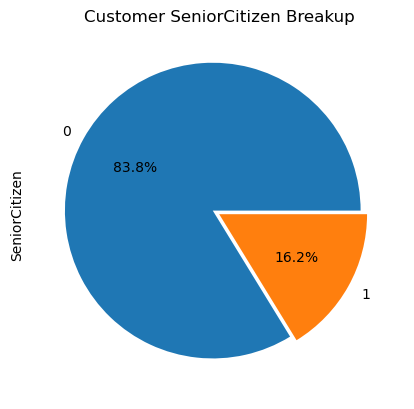

In [33]:
# There are only 16.2% of the customers who are senior citizens
# Thus most of the customers in the data are young people.

df3['SeniorCitizen'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode = (0.05,0))

plt.title('Customer SeniorCitizen Breakup')

plt.show()

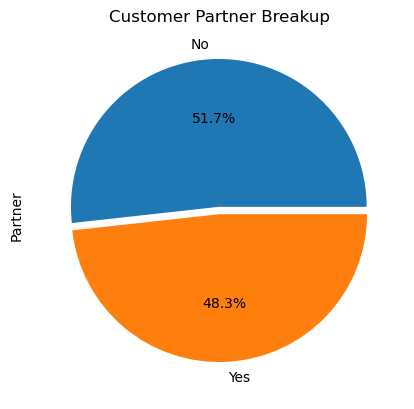

In [34]:
# Nearly half of total customers have a partner

df3['Partner'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode = (0.05,0))

plt.title('Customer Partner Breakup')

plt.show()

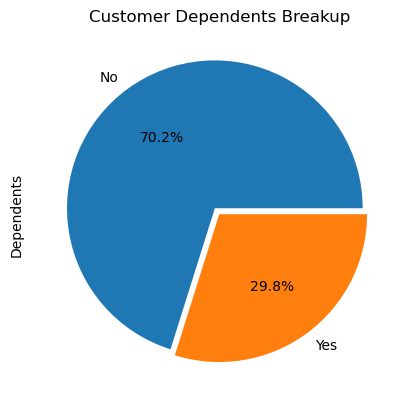

In [35]:
# only 30% of the total customers have dependents.

df3['Dependents'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode = (0.05,0))

plt.title('Customer Dependents Breakup')

plt.show()

## B.) Customer Account Information

  Let us now look at the tenure, contract, payment method, paperless billing.

Text(0.5, 1.0, 'Number of Customers by their tenure')

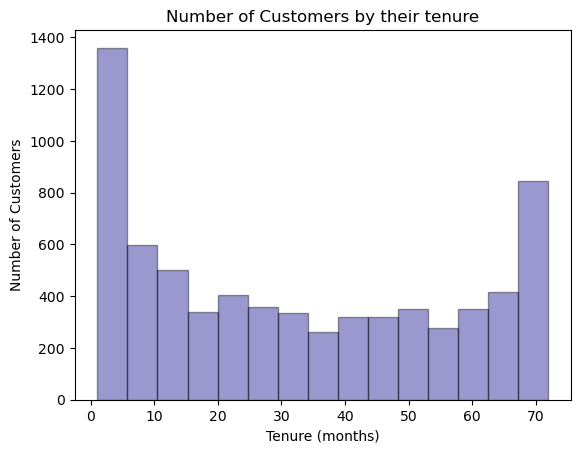

In [36]:
ax = sns.distplot(df3['tenure'], hist=True, kde=False, 
              color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Tenure (months)')
ax.set_title('Number of Customers by their tenure')

1. Tenure: 
           After looking at the above histogram we can see that a lot of customers have been with 
           the telecom company for just a month, while quite a many are there for about 72 months. 
           This could be potentially because different customers have different contracts. 
           Thus based on the contract they are into it could be more/less easier for the customers 
           to churn or not the telecom company.During the middle of the total tenure their are 
           minimum customers.

Text(0.5, 1.0, 'Number of Customers by Contract Type')

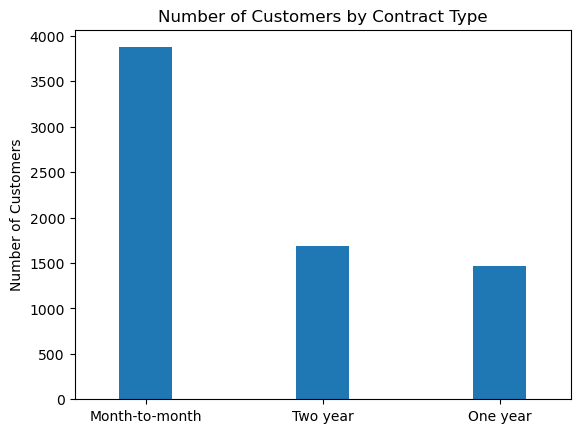

In [37]:
ax = df3['Contract'].value_counts().plot(kind = 'bar',rot = 0, width = 0.3)
ax.set_ylabel('Number of Customers')
ax.set_title('Number of Customers by Contract Type')

2. Contracts: 
        we can see from the bar diagram above that most of the customers are in the month to month contract. 
        While there are almost equal number of customers in the 1 year and 2 year contracts. 
        The number of customers in 1 year contract are minimum.

Text(0.5, 1.0, 'Number of Customers by Contract Type')

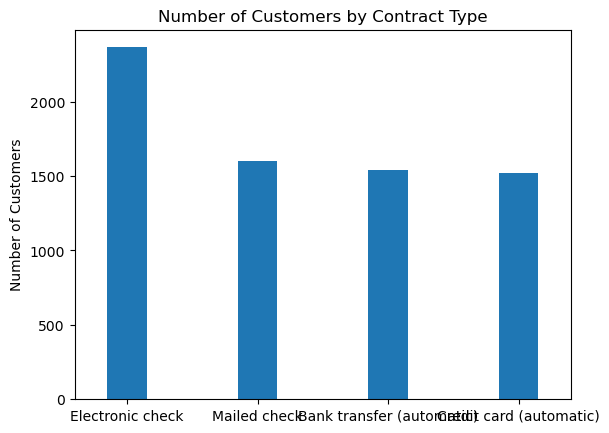

In [38]:
ax = df3['PaymentMethod'].value_counts().plot(kind = 'bar',rot = 0, width = 0.3)
ax.set_ylabel('Number of Customers')
ax.set_title('Number of Customers by Contract Type')

3. Payment method:
                 There are 4 different methods of payments.
                 'Electronic check' is the top choice of payment by the customers.
                 All other 3 methods of payments have almost equal frequency of occurence.

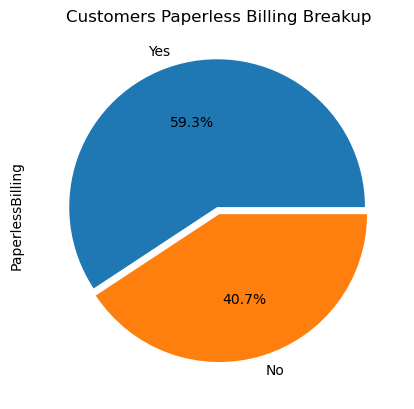

In [39]:
df3['PaperlessBilling'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode = (0.05,0))

plt.title('Customers Paperless Billing Breakup')

plt.show()

4. Paperless billing:
    
                     From the pie-diagram above, it is evident that about 60% customers are environment
                     conscious and have a choice for PaperlessBilling.

## C.) Distribution of various services used by customers

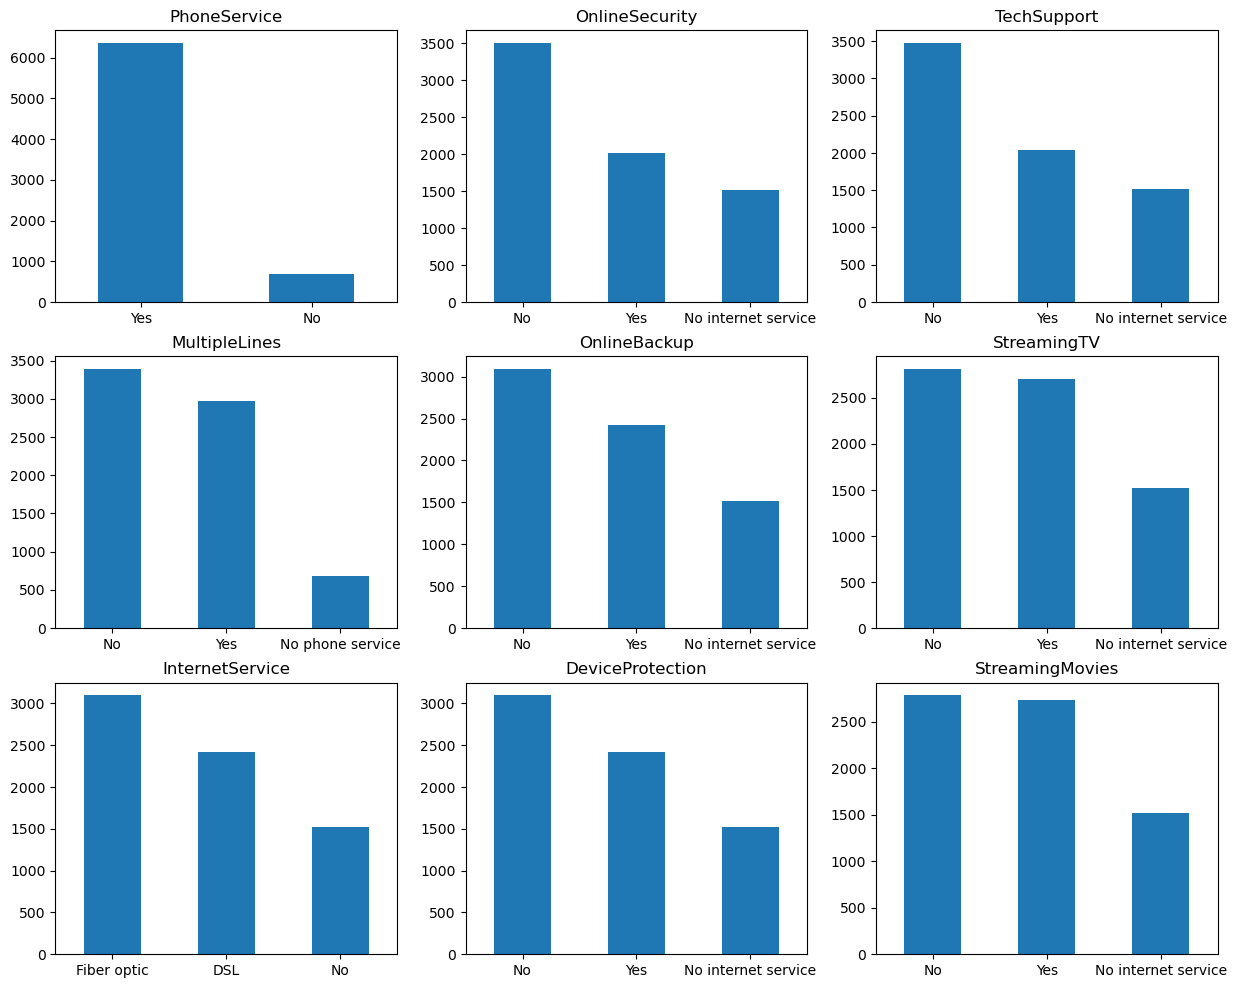

In [40]:
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
           'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (15,12))
for i, item in enumerate(services):
    if i < 3:
        ax = df3[item].value_counts().plot(kind = 'bar',ax=axes[i,0],rot = 0)
        
    elif i >=3 and i < 6:
        ax = df3[item].value_counts().plot(kind = 'bar',ax=axes[i-3,1],rot = 0)
        
    elif i < 9:
        ax = df3[item].value_counts().plot(kind = 'bar',ax=axes[i-6,2],rot = 0)
        
    ax.set_title(item)

## Conclusions:

1. Most of the customers avail 'PhoneService'. Almost 3500 customers have no online security, 1500  have no 
   internet service and only almost 2000 avail online security feature. Almost same trend in TechSupport.
    
2. About 3400 customers dont have Multiplelines,more than 2400 have multiple lines and almost 600 have no phone 
   service. More than 3000 customers don't have online backup and 1500 customers have No internet service 
   for Onlinebackup.

3. Fiber optics is the top choice for internetservice, followed by DSL, DeviceProtection is not the priority of 
   more than 3000 customers, almost equal number of customers have option for StreamingMovies and not 
   StreamingMovies.



## Bivariate Analysis

In [41]:
# There are only three continuous variables

continuous_cols = ['tenure','MonthlyCharges','TotalCharges']

df3[continuous_cols].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


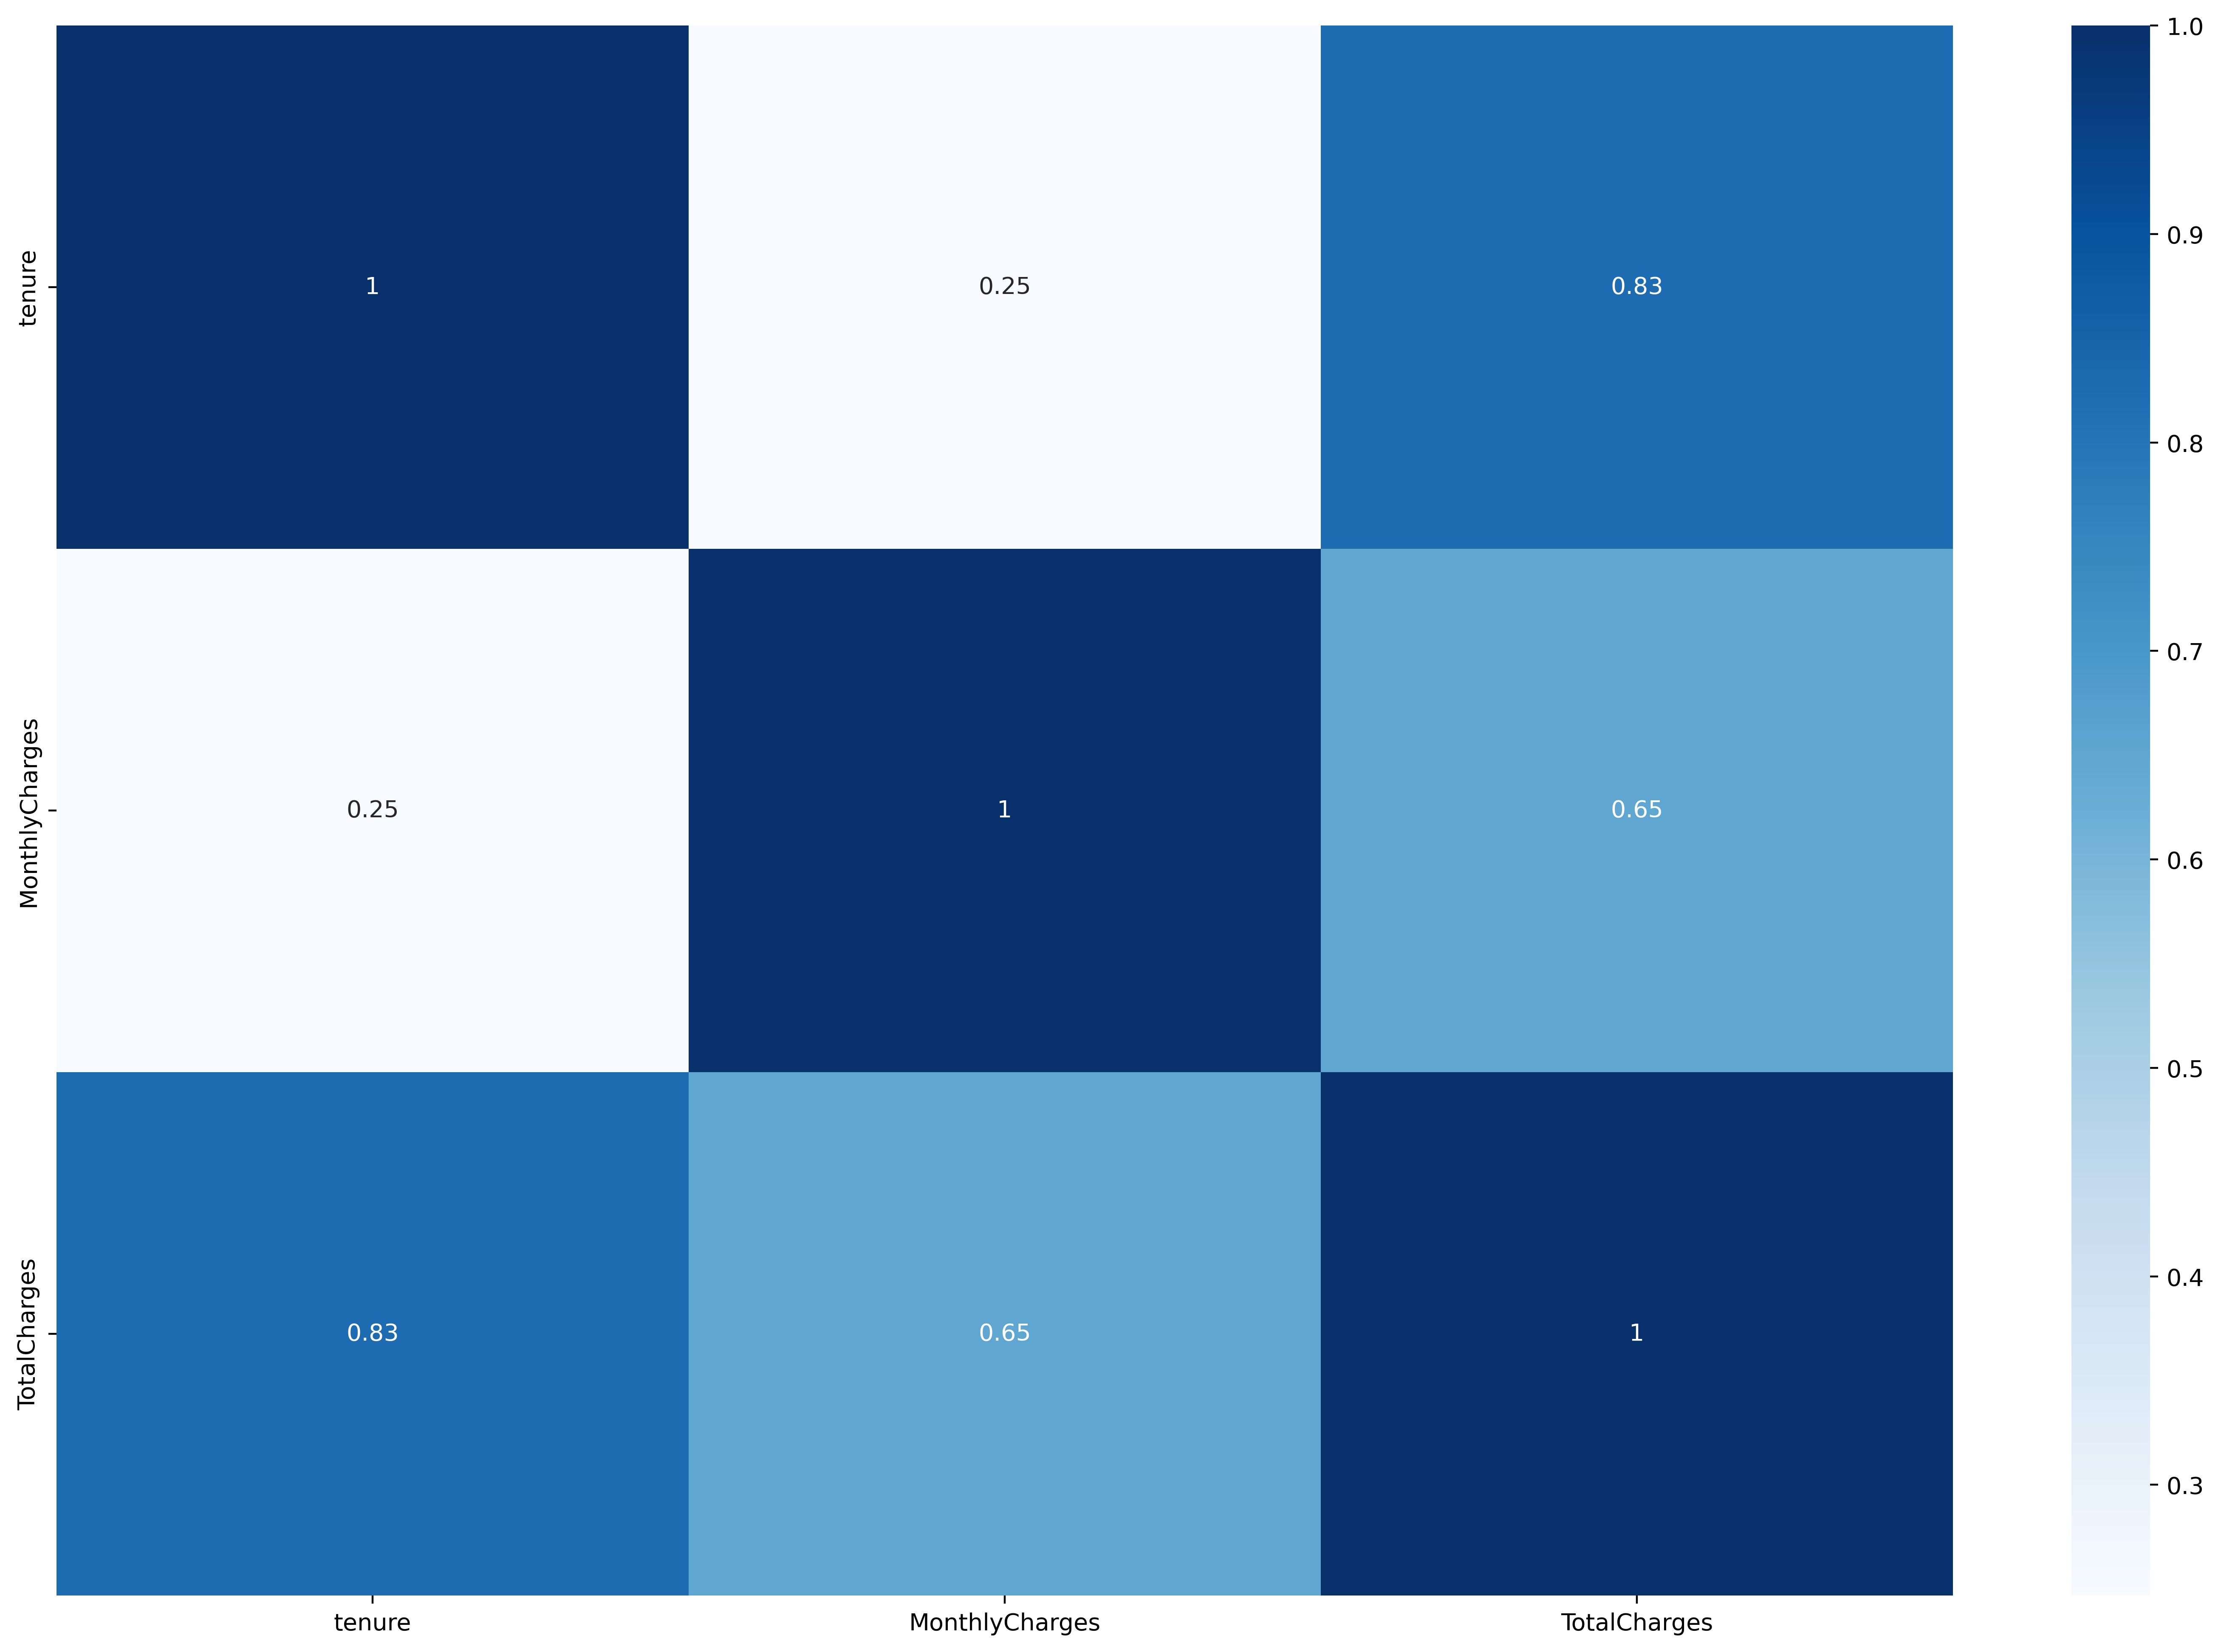

In [42]:
## lets visualize the above correlation between continuous variables using heatmap

# tenure and total charges are highly correlated that is, larger the
# tenure higher the total charges.
# Tenure and Monthly charges are feebly correlated.
# MonthlyCharges and TotalCharges are also correlated, means that higher the monthly charges, higher will 
# be the total charges

plt.figure(figsize=(18, 12), dpi=400)
sns.heatmap(df3[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True, cmap='Blues')
plt.show()

Text(0, 0.5, 'StreamingMovies')

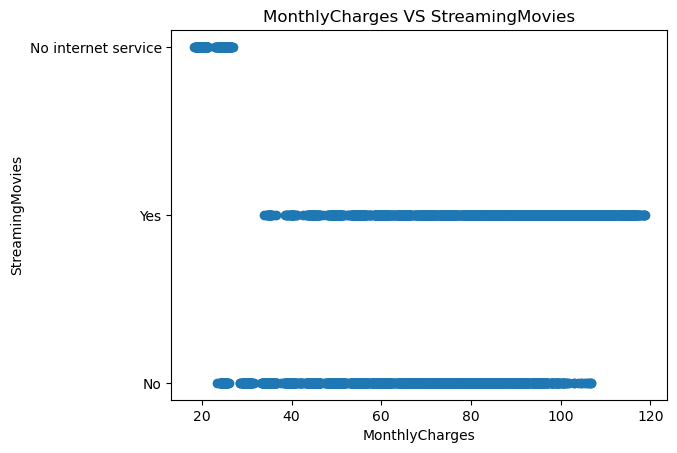

In [43]:
#create scatterplot of MonthlyCharges vs. StreamingMovies
# Customers who are StreamingMovies with No internet service have to pay very less MonthlyCharges
# Customers who are StreamingMovies, their monthly charges starts with a larger amount and also ends with 
# the highest amount as compared to those who don't StreamMovies.

plt.scatter(df3.MonthlyCharges, df3.StreamingMovies)
plt.title('MonthlyCharges VS StreamingMovies')
plt.xlabel('MonthlyCharges')
plt.ylabel('StreamingMovies')

<AxesSubplot:xlabel='SeniorCitizen', ylabel='count'>

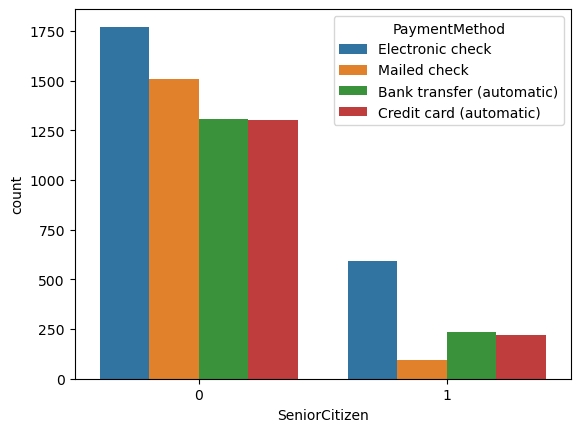

In [44]:
# Mostly Senior Citizens don't make payments
# Top choice of payment method among Senior citizens is through 'Electronic Cheque'
# Least used method among SeniorCitizen is through 'Mailed Cheque'

sns.countplot(x = 'SeniorCitizen', hue = 'PaymentMethod', data = df3)

<AxesSubplot:xlabel='gender', ylabel='count'>

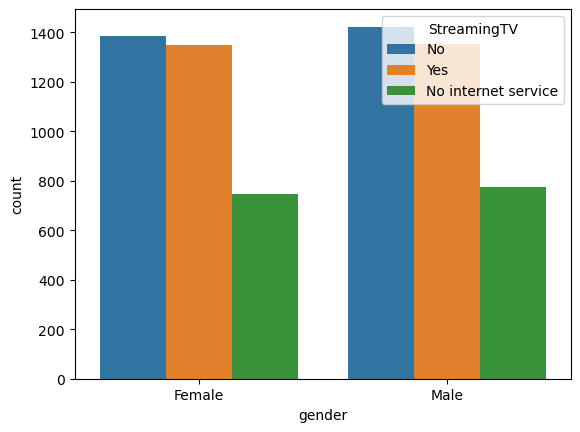

In [45]:
# count plot on two categorical variable
 
# Highest Number of Male and Female customers are not streaming TV followed by those who are streamingTV
# There are almost an equal number of Male and Female customers who have no internet service 
# but they are StreamingTV.

sns.countplot(x ='gender', hue = 'StreamingTV', data = df3)

<AxesSubplot:xlabel='Dependents', ylabel='count'>

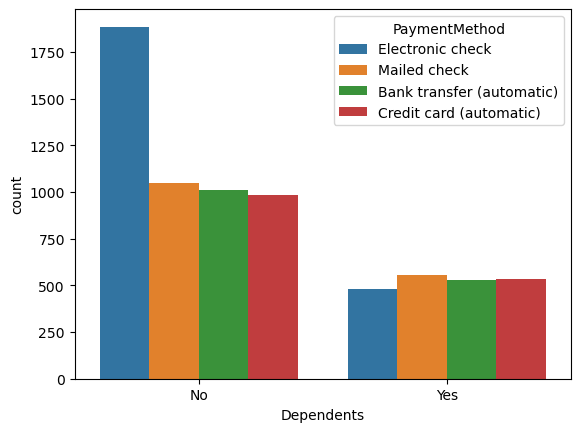

In [46]:
# The dependents generally don't make payments
# Top choice of payments by dependents of customers is through 'Mailed Check'. 
# Most Customers with No dependents make their payments through 'Electronic Check'

sns.countplot(x = 'Dependents', hue = 'PaymentMethod', data = df3)

<AxesSubplot:xlabel='gender', ylabel='count'>

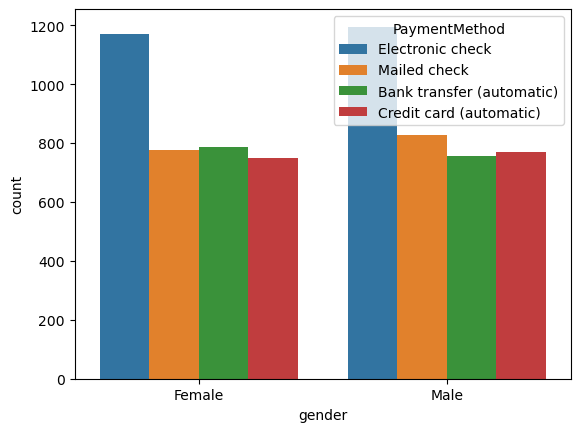

In [47]:
# 'Electronic Check' is the most favourite method of payment by Males and Females.
# Least used method of payment among Females is 'Credit card(automatic)' 
# Least used method among Males is through 'Bank Transfer(automatic)'

sns.countplot(x = 'gender', hue = 'PaymentMethod', data = df3)

Text(0.5, 1.0, 'Distribution of total charges by churn')

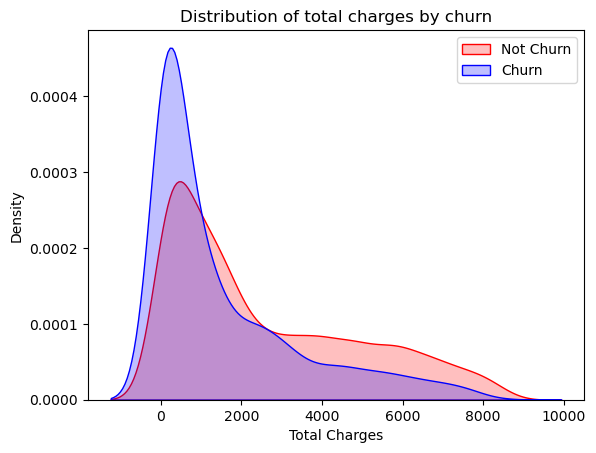

In [48]:
# It is evident from the KDE-plot below that there is the highest churn when the total charges are low. 
# Higher Total Charges leads to no churn. 

ax = sns.kdeplot(df3.TotalCharges[(df3["Churn"] == 'No')],
                color="Red", shade = True)
ax = sns.kdeplot(df3.TotalCharges[(df3["Churn"] == 'Yes')],
                ax=ax, color="Blue", shade= True)
ax.legend(["Not Churn","Churn"],loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Total Charges')
ax.set_title('Distribution of total charges by churn')

Text(0.5, 1.0, 'Distribution of tenure by churn')

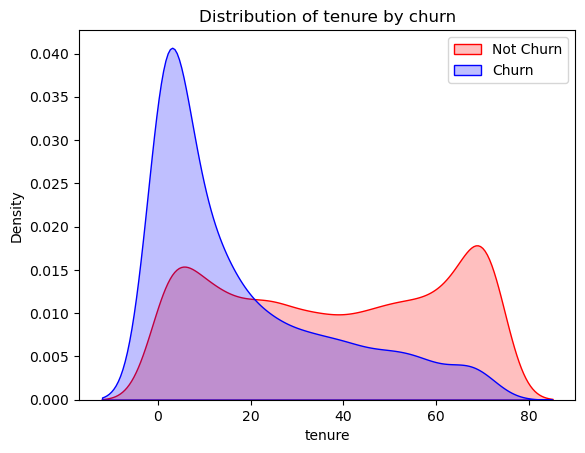

In [49]:
# It seems that there is higer churn during the initial months
# After a duration of almost 20 months the density of customers who do not churn is higher than those who churned
# Their is a peak around duration of 70 months when the customers do not churn

ax = sns.kdeplot(df3.tenure[(df3["Churn"] == 'No')],
                color="Red", shade = True)
ax = sns.kdeplot(df3.tenure[(df3["Churn"] == 'Yes')],
                ax=ax, color="Blue", shade= True)
ax.legend(["Not Churn","Churn"],loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('tenure')
ax.set_title('Distribution of tenure by churn')

<AxesSubplot:xlabel='MonthlyCharges', ylabel='TotalCharges'>

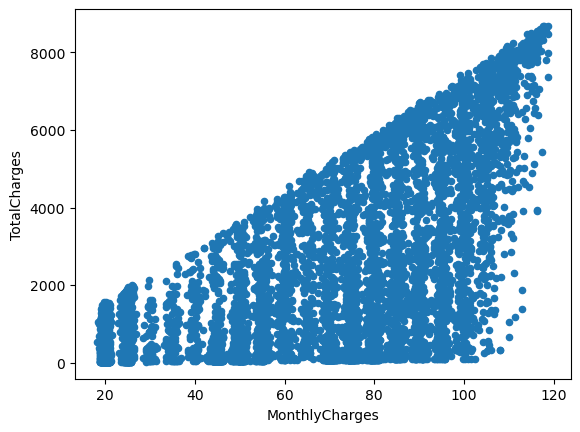

In [50]:
# It is observed that the total charges increase as the monthly bill for a customer increases.
# For small fixed values of TotalCharges the monthly charges increase 

df3[['MonthlyCharges', 'TotalCharges']].plot.scatter(x = 'MonthlyCharges',y='TotalCharges')

# Model Building

### Converting some binary variables (Yes/No) to 0/1

In [51]:
# List of variables to map

varlist =  ['PhoneService', 'PaperlessBilling', 'Churn', 'Partner', 'Dependents']

# Defining the map function
def binary_map(x):
    return x.map({'Yes': 1, "No": 0})

# Applying the function to the housing list
df3[varlist] = df3[varlist].apply(binary_map)

In [52]:
df3.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## For categorical variables with multiple labels, create dummy features

In [53]:
# Creating a dummy variable for some of the categorical variables and dropping the first one and
# adding the results to the master dataframe

var_dummy = pd.get_dummies(df3[['Contract', 'PaymentMethod', 'gender', 'InternetService']], drop_first=True)

df3 = pd.concat([df3, var_dummy], axis=1)

In [54]:
df3.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,29.85,0,0,0,0,1,0,0,0,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,1889.50,0,1,0,0,0,1,1,0,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,108.15,1,0,0,0,0,1,1,0,0
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,1840.75,0,1,0,0,0,0,1,0,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,151.65,1,0,0,0,1,0,0,1,0


In [55]:
# Encoding the remaining categorical variables
# Creating dummy variables for the remaining multi-label categorical variables 
# and dropping the level with big names.

# Creating dummy variables for the variable 'MultipleLines'
d1 = pd.get_dummies(df3['MultipleLines'], prefix='MultipleLines')

# Dropping MultipleLines_No phone service column
d2 = d1.drop(['MultipleLines_No phone service'], 1)

#Adding the results to the original dataframe
df3 = pd.concat([df3,d2], axis=1)

# Creating dummy variables for the variable 'OnlineSecurity'.
d3 = pd.get_dummies(df3['OnlineSecurity'], prefix='OnlineSecurity')

# Dropping OnlineSecurity_No internet service column
d4 = d3.drop(['OnlineSecurity_No internet service'], 1)

# Adding the results to the original dataframe
df3 = pd.concat([df3,d4], axis=1)

# Creating dummy variables for the variable 'OnlineBackup'.
d5 = pd.get_dummies(df3['OnlineBackup'], prefix='OnlineBackup')

# Dropping OnlineBackup_No internet service column
d6 = d5.drop(['OnlineBackup_No internet service'], 1)

# Adding the results to the master dataframe
df3 = pd.concat([df3,d6], axis=1)

# Creating dummy variables for the variable 'DeviceProtection'. 
d7 = pd.get_dummies(df3['DeviceProtection'], prefix='DeviceProtection')

# Dropping DeviceProtection_No internet service column
d8 = d7.drop(['DeviceProtection_No internet service'], 1)

# Adding the results to the original dataframe
df3 = pd.concat([df3,d8], axis=1)

# Creating dummy variables for the variable 'TechSupport'. 
d9 = pd.get_dummies(df3['TechSupport'], prefix='TechSupport')

# Dropping TechSupport_No internet service column
d10 = d9.drop(['TechSupport_No internet service'], 1)

# Adding the results to the original dataframe
df3 = pd.concat([df3,d10], axis=1)

#Creating dummy variables for the variable 'StreamingTV'.
d11 =pd.get_dummies(df3['StreamingTV'], prefix='StreamingTV')

# Dropping StreamingTV_No internet service column
d12 = d11.drop(['StreamingTV_No internet service'], 1)

# Adding the results to the original dataframe
df3 = pd.concat([df3,d12], axis=1)

# Creating dummy variables for the variable 'StreamingMovies'. 
d13 = pd.get_dummies(df3['StreamingMovies'], prefix='StreamingMovies')

# Dropping StreamingMovies_No internet service column
d14 = d13.drop(['StreamingMovies_No internet service'], 1)

# Adding the results to the original dataframe
df3 = pd.concat([df3,d14], axis=1)

In [56]:
df3.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,0,1,1,0,1,0,1,0,1,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,1,0,0,1,1,0,1,0,1,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,0,1,1,0,1,0,1,0,1,0
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,1,0,0,1,0,1,1,0,1,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,1,0,1,0,1,0,1,0,1,0


In [57]:
# As we have created dummies for the below 11 variables, so we should drop them from the original dataframe.

df3 = df3.drop(['gender','MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies','Contract','PaymentMethod'], 1)

In [58]:
# All the variables have been converted into numeric
# Only customerID is object type
df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   object 
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  Contract_One year                      7032 non-null   uint8  
 11  Cont

In [59]:
# Dropping the 'customerID' column which is redundant for the analysis

df = df3.drop(['customerID'], axis = 1)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Contract_One year,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,0,1,0,1,0,1,29.85,29.85,0,0,...,0,1,1,0,1,0,1,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,0,1,...,1,0,0,1,1,0,1,0,1,0
2,0,0,0,2,1,1,53.85,108.15,1,0,...,0,1,1,0,1,0,1,0,1,0
3,0,0,0,45,0,0,42.30,1840.75,0,1,...,1,0,0,1,0,1,1,0,1,0
4,0,0,0,2,1,1,70.70,151.65,1,0,...,1,0,1,0,1,0,1,0,1,0


## 3. Data Preparation for model building: [ Score: 2 point ]

1. Standardize the columns using z-score scaling approach.
2. Split the dataset into two parts (i.e. 70% train and 30% test).
3. Store the target column (i.e. Churn) in the y variable and the rest of the columns in the X variable.

## Test-Train Split

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
# Putting feature variable to X

X = df.drop(['Churn'], axis=1)

X.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,0,1,0,1,0,1,29.85,29.85,0,0,...,0,1,1,0,1,0,1,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,1,0,...,1,0,0,1,1,0,1,0,1,0
2,0,0,0,2,1,1,53.85,108.15,0,0,...,0,1,1,0,1,0,1,0,1,0
3,0,0,0,45,0,0,42.30,1840.75,1,0,...,1,0,0,1,0,1,1,0,1,0
4,0,0,0,2,1,1,70.70,151.65,0,0,...,1,0,1,0,1,0,1,0,1,0


In [62]:
# Putting response variable to y
y = df['Churn']

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## 4. Model training, and testing: [ Score: 6 point ]

In [63]:
# Splitting the predictor and target variables into training and test in the ratio 70:30.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [64]:
# # Applying z-score scaler to standardize the predictor columns in our model

# convert all attributes to Z scale 

from scipy.stats import zscore

X_train.apply(zscore)  

X_train.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
1675,0,0,0,29,1,1,78.90,2384.15,0,0,...,1,0,1,0,1,0,0,1,1,0
4154,0,0,0,6,1,1,74.90,469.80,0,0,...,1,0,1,0,1,0,1,0,1,0
5542,0,1,0,67,1,0,86.15,5883.85,0,1,...,0,1,0,1,0,1,0,1,0,1
3039,1,1,0,72,0,1,64.45,4641.10,0,1,...,0,1,0,1,0,1,0,1,0,1
3671,0,0,0,1,1,1,75.10,75.10,0,0,...,1,0,1,0,1,0,1,0,1,0


## Fitting the Logistic Regression Model

1. Train and test Logistic regression, KNN, and Naive Bayes models taught in the learning module.
2. Display the classification accuracies for train and test data.
3. Display and compare all the models designed with their train and test accuracies.
4. Select the final best trained model along with your detailed comments for selecting this model.

In [65]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [66]:
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

## Evaluate the model

In [67]:
cm_train = confusion_matrix(y_train , y_train_pred)
cm_test = confusion_matrix(y_test , y_test_pred)

In [68]:
#  confusion matrix

from sklearn import metrics

print(metrics.confusion_matrix(y_test, y_test_pred))

[[1385  176]
 [ 227  322]]


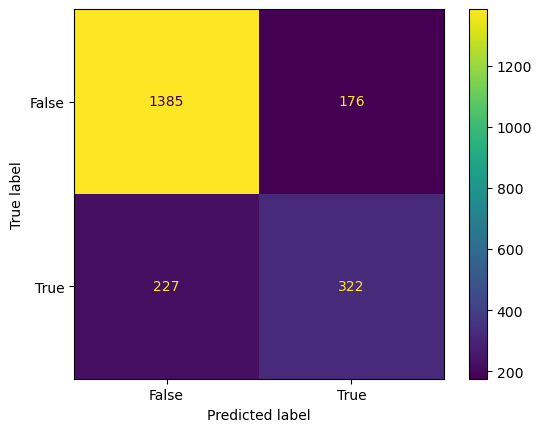

In [69]:
## Confusion matrix applied on test

cm_display_test = ConfusionMatrixDisplay(confusion_matrix = cm_test, display_labels = [False, True])
cm_display_test.plot()
plt.show()

In [70]:
accu_score_train = accuracy_score(y_train , y_train_pred)
accu_score_test = accuracy_score(y_test , y_test_pred)

In [71]:
print(f"Accuracy Score in Training Data in Logistic Model is : {accu_score_train.round(4)}")
print(f"Accuracy Score in Test Data in Logistic Model is : {accu_score_test.round(4)}")

Accuracy Score in Training Data in Logistic Model is : 0.8029
Accuracy Score in Test Data in Logistic Model is : 0.809


In [72]:
## Compute precision, recall and F1-score

y_test_pred_log_reg = log_reg.predict(X_test)

print(classification_report(y_test,y_test_pred_log_reg))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1561
           1       0.65      0.59      0.62       549

    accuracy                           0.81      2110
   macro avg       0.75      0.74      0.74      2110
weighted avg       0.80      0.81      0.81      2110



## Conclusion:

According to confusion matrix there are total 1385+176 = 1561 actual non-churn values and the 
algorithm predicts 1385 of them as non churn and 176 of them as churn. While there are 227+322 = 549
actual churn values and the algorithm predicts 227 of them as non churn values and 322 of them as churn values.

Accuracy is % 81

f1-score is % 62

## KNN Classification model

In [73]:
## Fit the KNN classifier model to the train dataset

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

## Evaluate the model

In [74]:
## compute y predicted train and test labels

y_pred_train_knn = knn.predict(X_train)
y_pred_test_knn = knn.predict(X_test)

In [75]:
#  confusion matrix

from sklearn import metrics

print(metrics.confusion_matrix(y_test, y_pred_test_knn))

[[1350  211]
 [ 292  257]]


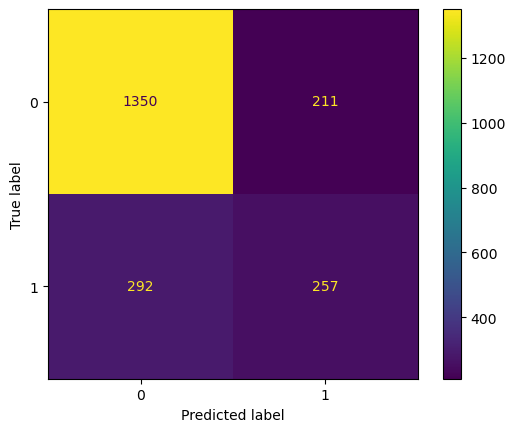

In [76]:
# Confusion matrix for test data

from sklearn.metrics import plot_confusion_matrix

plot_confusion_matrix(knn, X_test, y_test)  
plt.show()

In [77]:
## Compute precision, recall and F1-score

print(classification_report(y_test,y_pred_test_knn))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1561
           1       0.55      0.47      0.51       549

    accuracy                           0.76      2110
   macro avg       0.69      0.67      0.67      2110
weighted avg       0.75      0.76      0.76      2110



Conclusion:
    
According to confusion matrix there are total 1350+211 = 1561 actual non-churn values and
the algorithm predicts 1350 of them as non churn and 211 of them as churn. While there are 292+257= 549 
actual churn values and the algorithm predicts 292 of them as non churn values and 257 of them as churn values.

Accuracy is % 76

f1-score is % 51

In [78]:
## accuracy in train data
## accuracy in test data

ac_score_train = accuracy_score(y_train , y_pred_train_knn)
ac_score_test = accuracy_score(y_test , y_pred_test_knn)

print(f"Accuracy Score in Training Data is : {ac_score_train.round(4)}")
print(f"Accuracy Score in Test Data is : {ac_score_test.round(4)}")

Accuracy Score in Training Data is : 0.831
Accuracy Score in Test Data is : 0.7616


## Choosing optimal K value

In KNN Choice of k is very critical. A small value of k means that noise will have a higher influenceon the 
result.A large value makes it computationally expensive and is contradictory to the basic idea behind KNN, 
that close points might have similar densities or classes.The default parameter for the number of neighbors 
k is 5.

In [79]:
# Error rate

error_rate = []

for i in range(1,30):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

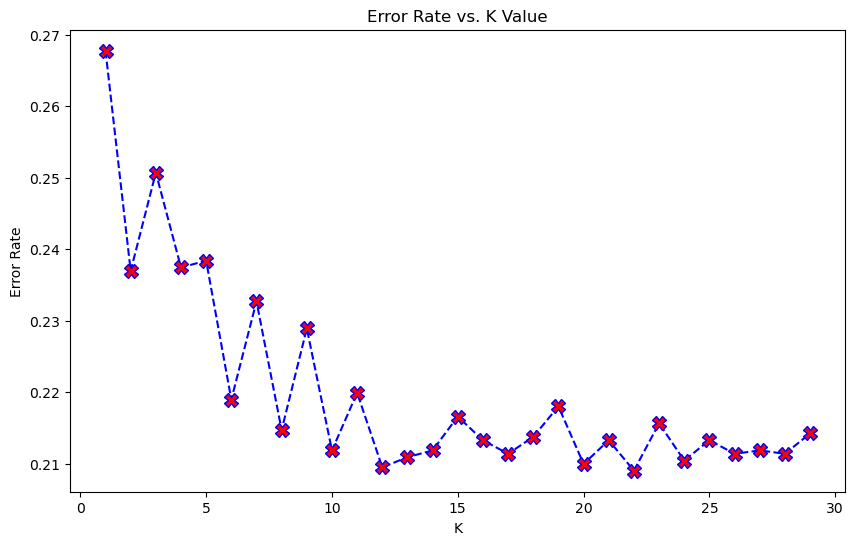

In [80]:
# From the plot, we can observe that the error is lowest for 28 neigbours, 
# lets build KNN classifier using this K value and compare the accuracy

plt.figure(figsize=(10,6))
plt.plot(range(1,30),error_rate,color='blue', linestyle='dashed', marker='X',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

## Model 2: KNN classfier with optimal K=22

In [81]:
# We can observe that when we built models using the optimal k value 
# (having least error rate), the model accuracy is increased by 1 - 2%

knn_K = KNeighborsClassifier(n_neighbors=22)
knn_K.fit(X_train,y_train)

## y predicted
y_pred_knn_K = knn_K.predict(X_test)

## accuracy
print('accuracy(K):',accuracy_score(y_test,y_pred_knn_K))

accuracy(K): 0.7909952606635071


## Naive Bayes Classification model

In [82]:
#  Instantiate the Gaussian Naive Bayes module from SKlearn GaussianNB. 
# To fit the model, we pass x_train and y_train

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

## Evaluate the model

In [83]:
# compute y predicted train and test labels

y_pred_train_gnb = gnb.predict(X_train)
y_pred_test_gnb = gnb.predict(X_test)

In [84]:
#  confusion matrix

print(metrics.confusion_matrix(y_test, y_pred_test_gnb))

[[1112  449]
 [ 121  428]]


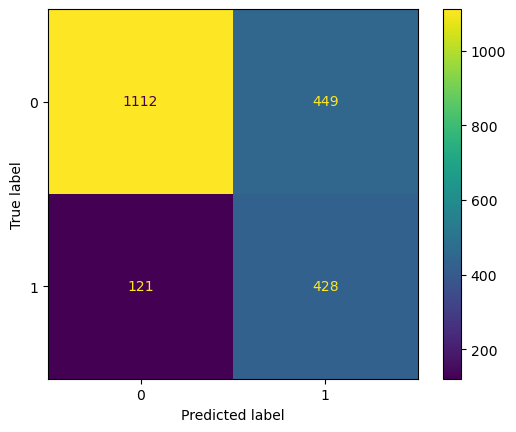

In [85]:
# Confusion matrix applied on test

plot_confusion_matrix(gnb, X_test, y_test)  
plt.show()

In [86]:
# Compute precision, recall and F1-score

print(classification_report(y_test,y_pred_test_gnb))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1561
           1       0.49      0.78      0.60       549

    accuracy                           0.73      2110
   macro avg       0.69      0.75      0.70      2110
weighted avg       0.79      0.73      0.75      2110



## Conclusion:

        According to confusion matrix there are total 1112+449 = 1561 actual non-churn values 
        and the algorithm predicts 1112 of them as non churn and 449 of them as churn.
        While there are 121+428 = 549 actual churn values and the algorithm predicts 121 of them as 
        non churn values and 428 of them as churn values.
        
Accuracy is % 73

f1-score is % 60

In [87]:
# accuracy in train data
# accuracy in test data

ac_score_train = accuracy_score(y_train , y_pred_train_gnb)
ac_score_test = accuracy_score(y_test , y_pred_test_gnb)
print(f"Accuracy Score in Training Data is : {ac_score_train.round(4)}")
print(f"Accuracy Score in Test Data is : {ac_score_test.round(4)}")

Accuracy Score in Training Data is : 0.7363
Accuracy Score in Test Data is : 0.7299


###  Comparison of Logistic Regression classifier, KNN classfier and Naive Bayes Classification models

In [88]:
print('Logistic Regression classification model-accuracy:', accuracy_score(y_test,y_test_pred_log_reg).round(4))
print('knn classifier Model with optimal K-accuracy:', accuracy_score(y_test,y_pred_knn_K).round(4))
print('Naive Bayes Classification model-accuracy:', accuracy_score(y_test,y_pred_test_gnb).round(4))

Logistic Regression classification model-accuracy: 0.809
knn classifier Model with optimal K-accuracy: 0.791
Naive Bayes Classification model-accuracy: 0.7299


## 5. Conclusion and improvisation:

Based on the classification reports showing the precision, recall, and F1-score for the three models, 
Logistic Regression, KNN, and Naive Bayes the following may be concluded:
    
Based on these classification reports, it can be concluded that Logistic Regression has the 
highest accuracy and performs the best among the three models. Naive Bayes has the lowest accuracy 
and performs the worst among the three models.

In KNN Model finding optimal value of K certainly improves upon the accuracy score from 0.7616 to 0.791.

However, it is important to note that accuracy alone may not be the best metric to evaluate the 
performance of a model, other factors such as the balance of the dataset and the cost of false positives
and false negatives should also be taken into consideration.


Based on the above data, some possible improvisations that can be considered are:

1. Feature selection: It may be worthwhile to evaluate the importance of the features used in the models 
   and consider selecting a subset of the most relevant features. This can help improve the performance 
   of the models and reduce the risk of overfitting.
    
2. Balancing the dataset: The dataset appears to be imbalanced, with more data points in class 0 than class 1. 
   Balancing the dataset using techniques such as oversampling or undersampling may help improve the performance
   of the models.   